<a href="https://colab.research.google.com/github/Shedjohn/A-B-Testing-Analytics/blob/main/A_B_testing_analytics_for_a_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Mount Drive**

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load Data**

In [54]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/ab_data(ab testing).csv")

**EDA**

In [55]:
#first 5
df.head()
#check dimesions
df.shape
#ispect columns
df.columns
#understand dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


**convert**

In [56]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

**Check Missing Values**

In [57]:
df.isnull().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0


**Dupliates**

In [58]:
df.duplicated().sum()

df["user_id"].duplicated().sum()

np.int64(3894)

**Examine the experimental groups**

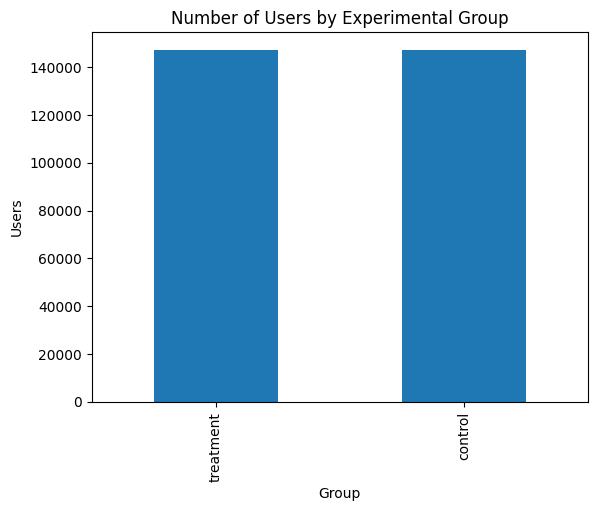

In [59]:
df["group"].value_counts()

df["group"].value_counts().plot(kind="bar")
plt.title("Number of Users by Experimental Group")
plt.xlabel("Group")
plt.ylabel("Users")
plt.show()

**Check the landing pages**

In [60]:
df["landing_page"].value_counts()

,count
landing_page,
old_page,147239
new_page,147239


**Check group vs landing page**

In [61]:
pd.crosstab(df["group"], df["landing_page"])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


**Identify the mismatched observations**

In [62]:
mismatch = (
    ((df["group"] == "control") & (df["landing_page"] == "new_page"))
    |
    ((df["group"] == "treatment") & (df["landing_page"] == "old_page"))
)

df[mismatch].head()

mismatch.sum()

np.int64(3893)

**Create a clean experimental dataset**

In [63]:
df_clean = df[
    ((df["group"] == "control") & (df["landing_page"] == "old_page"))
    |
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
].copy()

df_clean.shape

(290585, 5)

In [64]:
pd.crosstab(
    df_clean["group"],
    df_clean["landing_page"]
)

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


**Check the conversion variable**

In [65]:
df_clean["converted"].value_counts()

df_clean["converted"].unique()

array([0, 1])

**Check conversion rate**

In [66]:
df_clean.groupby("group")["converted"].mean()

,converted
group,
control,0.120386
treatment,0.118807


**Calculate conversions and users together**

In [67]:
summary = df_clean.groupby("group")["converted"].agg(
    users="count",
    conversions="sum",
    conversion_rate="mean"
)

summary

,users,conversions,conversion_rate
group,,,
control,145274,17489,0.120386
treatment,145311,17264,0.118807


In [68]:
summary["conversion_rate"] *= 100
summary

,users,conversions,conversion_rate
group,,,
control,145274,17489,12.038630
treatment,145311,17264,11.880725


**Visualize conversion rates**

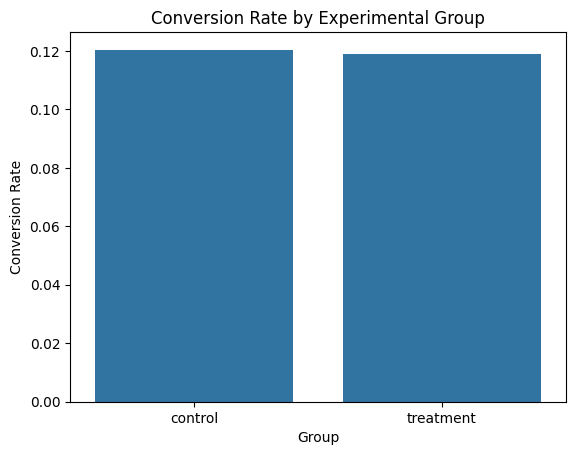

In [69]:
conversion_rates = (
    df_clean.groupby("group")["converted"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=conversion_rates,
    x="group",
    y="converted"
)

plt.title("Conversion Rate by Experimental Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")

plt.show()

**Get the two groups**

In [70]:
control = df_clean[df_clean["group"] == "control"]
treatment = df_clean[df_clean["group"] == "treatment"]

print("Control users:", len(control))
print("Treatment users:", len(treatment))

Control users: 145274
Treatment users: 145311


**Calculate conversions**

In [71]:
control_conversions = control["converted"].sum()
treatment_conversions = treatment["converted"].sum()

print("Control conversions:", control_conversions)
print("Treatment conversions:", treatment_conversions)

Control conversions: 17489
Treatment conversions: 17264


In [72]:
control_rate = control["converted"].mean()
treatment_rate = treatment["converted"].mean()

print("Control conversion rate:", control_rate)
print("Treatment conversion rate:", treatment_rate)

Control conversion rate: 0.1203863045004612
Treatment conversion rate: 0.11880724790277405


In [73]:
print(f"Control conversion rate: {control_rate:.4%}")
print(f"Treatment conversion rate: {treatment_rate:.4%}")

Control conversion rate: 12.0386%
Treatment conversion rate: 11.8807%


**Compare the two rates**

In [74]:
absolute_lift = treatment_rate - control_rate

print(f"Absolute lift: {absolute_lift:.4%}")

Absolute lift: -0.1579%


**Calculate relative lift**

In [75]:
relative_lift = (
    (treatment_rate - control_rate)
    / control_rate
)

print(f"Relative lift: {relative_lift:.2%}")

Relative lift: -1.31%


**Create a summary**

In [76]:
results = pd.DataFrame({
    "Group": ["Control", "Treatment"],
    "Users": [len(control), len(treatment)],
    "Conversions": [control_conversions, treatment_conversions],
    "Conversion Rate": [control_rate, treatment_rate]
})

results

,Group,Users,Conversions,Conversion Rate
0,Control,145274,17489,0.120386
1,Treatment,145311,17264,0.118807


In [77]:
#Format the conversion rate:
results["Conversion Rate"] = (
    results["Conversion Rate"] * 100
)

results

,Group,Users,Conversions,Conversion Rate
0,Control,145274,17489,12.038630
1,Treatment,145311,17264,11.880725


**Import the statistical test**

In [78]:
from statsmodels.stats.proportion import proportions_ztest

conversions = [
    control_conversions,
    treatment_conversions
]

sample_sizes = [
    len(control),
    len(treatment)
]

test_statistic, p_value = proportions_ztest(
    conversions,
    sample_sizes
)

print("Test statistic:", test_statistic)
print("p-value:", p_value)

Test statistic: 1.3116075339133115
p-value: 0.18965258971881804


**Interpret the p-value**

In [79]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Fail to reject the null hypothesis.


In [80]:
print(f"p-value = {p_value:.6f}")

p-value = 0.189653


**Confidence interval**

In [81]:
from statsmodels.stats.proportion import confint_proportions_2indep

In [82]:
ci_low, ci_high = confint_proportions_2indep(
    treatment_conversions,
    len(treatment),
    control_conversions,
    len(control),
    method="wald"
)

print("95% CI:")
print(f"Lower: {ci_low:.4%}")
print(f"Upper: {ci_high:.4%}")

95% CI:
Lower: -0.3939%
Upper: 0.0781%


**Put the statistical results together**

In [83]:
print("=" * 50)
print("A/B TEST RESULTS")
print("=" * 50)

print(f"Control conversion rate:   {control_rate:.4%}")
print(f"Treatment conversion rate: {treatment_rate:.4%}")
print(f"Absolute lift:             {absolute_lift:.4%}")
print(f"Relative lift:             {relative_lift:.2%}")
print(f"Test statistic:            {test_statistic:.4f}")
print(f"P-value:                   {p_value:.6f}")
print(f"95% CI:                    [{ci_low:.4%}, {ci_high:.4%}]")
print(f"Significance level:        {alpha}")

if p_value < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

A/B TEST RESULTS
Control conversion rate:   12.0386%
Treatment conversion rate: 11.8807%
Absolute lift:             -0.1579%
Relative lift:             -1.31%
Test statistic:            1.3116
P-value:                   0.189653
95% CI:                    [-0.3939%, 0.0781%]
Significance level:        0.05
Decision: Fail to reject H0


**Business Impact & Rollout Decision**

In [84]:
#Statistical significance
if p_value < alpha:
    statistical_result = "Statistically significant"
else:
    statistical_result = "Not statistically significant"

print(statistical_result)

Not statistically significant


In [85]:
#Translate the lift into actual customers
monthly_visitors = 1_000_000

expected_control_conversions = (
    monthly_visitors * control_rate
)

expected_treatment_conversions = (
    monthly_visitors * treatment_rate
)

additional_conversions = (
    expected_treatment_conversions
    - expected_control_conversions
)

print(
    f"Expected additional conversions: "
    f"{additional_conversions:,.0f}"
)

Expected additional conversions: -1,579


**Add revenue**

In [86]:
revenue_per_conversion = 50

additional_revenue = (
    additional_conversions
    * revenue_per_conversion
)

print(
    f"Estimated additional monthly revenue: "
    f"${additional_revenue:,.2f}"
)

#reusable business-impact function
def estimate_business_impact(
    monthly_visitors,
    control_rate,
    treatment_rate,
    revenue_per_conversion
):
    control_conversions = monthly_visitors * control_rate
    treatment_conversions = monthly_visitors * treatment_rate

    additional_conversions = (
        treatment_conversions - control_conversions
    )

    additional_revenue = (
        additional_conversions
        * revenue_per_conversion
    )

    return {
        "control_conversions": control_conversions,
        "treatment_conversions": treatment_conversions,
        "additional_conversions": additional_conversions,
        "additional_revenue": additional_revenue
    }

Estimated additional monthly revenue: $-78,952.83


In [87]:
impact = estimate_business_impact(
    monthly_visitors=1_000_000,
    control_rate=control_rate,
    treatment_rate=treatment_rate,
    revenue_per_conversion=50
)

impact

{'control_conversions': np.float64(120386.3045004612),
 'treatment_conversions': np.float64(118807.24790277405),
 'additional_conversions': np.float64(-1579.0565976871585),
 'additional_revenue': np.float64(-78952.82988435793)}

**Build a decision rule**

In [88]:
if (
    p_value < alpha
    and treatment_rate > control_rate
    and absolute_lift > 0
):
    decision = "Recommend rollout"
else:
    decision = "Do not recommend immediate rollout"

print(decision)

Do not recommend immediate rollout


**Calculate sample size**

In [89]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [90]:
baseline_rate = control_rate

In [91]:
target_rate = baseline_rate + 0.01

In [92]:
effect_size = proportion_effectsize(
    baseline_rate,
    target_rate
)

In [93]:
power_analysis = NormalIndPower()

required_sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1
)

print(
    f"Required sample size per group: "
    f"{required_sample_size:.0f}"
)

Required sample size per group: 17209


**Calculate the power of our actual experiment**

In [94]:
actual_sample_size = min(
    len(control),
    len(treatment)
)

effect_size = proportion_effectsize(
    control_rate,
    control_rate + 0.01
)

actual_power = power_analysis.power(
    effect_size=effect_size,
    nobs1=actual_sample_size,
    alpha=0.05,
    ratio=1
)

print(f"Estimated statistical power: {actual_power:.2%}")

Estimated statistical power: 100.00%


**complete statistical scorecard**

In [95]:
ab_results = {
    "control_rate": control_rate,
    "treatment_rate": treatment_rate,
    "absolute_lift": absolute_lift,
    "relative_lift": relative_lift,
    "test_statistic": test_statistic,
    "p_value": p_value,
    "alpha": alpha,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "statistical_power": actual_power
}

ab_results

{'control_rate': np.float64(0.1203863045004612),
 'treatment_rate': np.float64(0.11880724790277405),
 'absolute_lift': np.float64(-0.0015790565976871451),
 'relative_lift': np.float64(-0.0131165800315857),
 'test_statistic': np.float64(1.3116075339133115),
 'p_value': np.float64(0.18965258971881804),
 'alpha': 0.05,
 'ci_low': np.float64(-0.00393867032963623),
 'ci_high': np.float64(0.0007805571342619391),
 'statistical_power': np.float64(0.9999999996796127)}

In [96]:
def make_ab_decision(
    control_rate,
    treatment_rate,
    p_value,
    alpha=0.05
):

    if p_value >= alpha:
        return "Do not roll out — insufficient statistical evidence."

    if treatment_rate <= control_rate:
        return "Do not roll out — treatment is not better than control."

    return "Recommend rollout — treatment shows statistically significant improvement."

In [97]:
decision = make_ab_decision(
    control_rate,
    treatment_rate,
    p_value
)

print(decision)

Do not roll out — insufficient statistical evidence.
